In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\kumar\OneDrive\Quikr_car.csv")
df.head(5)

,Unnamed: 0,Name,Label,Location,Price,Kms_driven,Fuel_type,Owner,Year,Company
0,0,Ford Figo Duratec Petrol EXI 1.2 - 2015,PLATINUM,Bangalore,"₹3,80,000","35,056 kms",Petrol,NaN,2015,Ford
1,1,Maruti Suzuki Wagon R VXI BS IV - 2016,PLATINUM,Bangalore,"₹4,65,000","44,000 kms",Petrol,NaN,2016,Maruti
2,2,Hyundai Creta 1.6 SX PLUS AUTO PETROL - 2018,PLATINUM,Bangalore,"₹13,50,000","42,917 kms",Petrol,NaN,2018,Hyundai
3,3,Hyundai Venue - 2019,PLATINUM,Chennai,"₹10,19,699","16,112 kms",Petrol,2nd Owner,2019,Hyundai
4,4,Honda Jazz - 2017,PLATINUM,Pune,"₹7,13,499","30,988 kms",Petrol,2nd Owner,2017,Honda


In [3]:
d=df.copy()

In [4]:
d['Price']=d['Price'].str.replace("₹","")
d['Price']=d['Price'].str.replace(",","")


In [5]:
d['Price']=d['Price'].replace("Ask For Price",np.nan)

In [6]:
d['Price']=d['Price'].astype(float)

In [7]:
d['Price']=d['Price'].fillna(d['Price'].mean())

In [8]:
d['Price']=d['Price'].astype(int)

In [9]:
d['Location']=d['Location'].fillna(d['Location'].mode()[0])

In [10]:
d['Owner']=d['Owner'].fillna(d['Owner'].mode()[0])

In [11]:
d['Kms_driven']=d['Kms_driven'].str.replace("kms","")
d['Kms_driven']=d['Kms_driven'].str.replace(",","")


In [12]:
d['Kms_driven']=d['Kms_driven'].astype(int)

In [13]:
d['Owner'].unique()

array([' 2nd Owner', ' 1st Owner', ' 3rd Owner'], dtype=object)

In [14]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [15]:
d['Owner_le']=le.fit_transform(d['Owner'])

In [16]:
d['Fuel_type']=d['Fuel_type'].str.replace(" ","")

In [17]:
d['Fuel_type_le']=le.fit_transform(d['Fuel_type'])

In [18]:
d['Fuel_type_le'].unique()

array([5, 1, 2, 0, 4, 6, 3])

In [19]:
d['Fuel_type'].unique()

array(['Petrol', 'Diesel', 'Electric', 'CNG', 'LPG', 'Petrol+CNG',
       'Hybrid'], dtype=object)

In [20]:
d['Location'].unique()

array(['Bangalore', 'Chennai', 'Pune', 'Hyderabad', 'Faridabad',
       'Kanchipuram', 'Kozhikode', 'Kolkata', 'Mumbai', 'Lucknow',
       'Coimbatore', 'Delhi', 'Nanded', 'Malappuram', 'Chandigarh',
       'Madurai', 'BolpurSantiniketan', 'Bhubaneswar', 'Pondicherry',
       'Udaipur', 'NaviMumbai', 'Gurgaon', 'Kurnool', 'Surat',
       'Ahmedabad', 'Jaipur', 'Thane', 'Nagpur', 'Dwarka', 'GirSomnath',
       'Anand', 'Muzaffarnagar', 'Trichy', 'Uttarpara', 'Kochi',
       'Dhanbad', 'Mahasamund', 'Bilaspur', 'Jagdalpur'], dtype=object)

In [21]:
d['Company'].unique()

array(['Ford', 'Maruti', 'Hyundai', 'Honda', 'Toyota', 'Jeep', 'Kia',
       'Tata', 'Audi', 'Renault', 'BMW', 'Nissan', 'MG', 'Mahindra',
       'Volkswagen', 'Volvo', 'Skoda', 'Jaguar', 'Mercedes', 'Ssangyong',
       'Fiat', 'Chevrolet', 'Datsun', 'Land', 'Porsche'], dtype=object)

In [22]:
q1=d['Price'].quantile(0.25)
q3=d['Price'].quantile(0.75)
q1,q3


(np.float64(411774.0), np.float64(786949.0))

In [23]:
iqr=q3-q1
iqr
min=q1-(1.5*iqr)
max=q3+(1.5*iqr)
min,max,iqr

(np.float64(-150988.5), np.float64(1349711.5), np.float64(375175.0))

In [24]:
Q1=d['Kms_driven'].quantile(0.25)
Q3=d['Kms_driven'].quantile(0.75)
Q1,Q3
IQR=Q3-Q1
MIN=Q1-(1.5*IQR)
MAX=Q3+(1.5*IQR)
MIN,MAX


(np.float64(-35676.25), np.float64(129667.75))

In [25]:
d1=d[(d['Price']<max) & (d['Kms_driven']<MAX)]

In [26]:
d1

,Unnamed: 0,Name,Label,Location,Price,Kms_driven,Fuel_type,Owner,Year,Company,Owner_le,Fuel_type_le
0,0,Ford Figo Duratec Petrol EXI 1.2 - 2015,PLATINUM,Bangalore,380000,35056,Petrol,2nd Owner,2015,Ford,1,5
1,1,Maruti Suzuki Wagon R VXI BS IV - 2016,PLATINUM,Bangalore,465000,44000,Petrol,2nd Owner,2016,Maruti,1,5
3,3,Hyundai Venue - 2019,PLATINUM,Chennai,1019699,16112,Petrol,2nd Owner,2019,Hyundai,1,5
4,4,Honda Jazz - 2017,PLATINUM,Pune,713499,30988,Petrol,2nd Owner,2017,Honda,1,5
5,5,Hyundai i20 - 2013,PLATINUM,Pune,391099,69163,Diesel,2nd Owner,2013,Hyundai,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1024,1024,Mahindra Xylo D2 BS IV - 2009,GOLD,Trichy,375000,115000,Diesel,2nd Owner,2009,Mahindra,1,1
1025,1025,Maruti Suzuki Eeco 5 STR - 2020,GOLD,Trichy,525000,13000,Petrol,2nd Owner,2020,Maruti,1,5
1026,1026,Maruti Suzuki Swift VDi ABS - 2018,GOLD,Delhi,550000,42000,Diesel,2nd Owner,2018,Maruti,1,1
1027,1027,Hyundai i10 Magna 1.2 - 2014,GOLD,Bangalore,229000,65000,Petrol,1st Owner,2014,Hyundai,0,5


In [27]:
d1.iloc[0:5]

,Unnamed: 0,Name,Label,Location,Price,Kms_driven,Fuel_type,Owner,Year,Company,Owner_le,Fuel_type_le
0,0,Ford Figo Duratec Petrol EXI 1.2 - 2015,PLATINUM,Bangalore,380000,35056,Petrol,2nd Owner,2015,Ford,1,5
1,1,Maruti Suzuki Wagon R VXI BS IV - 2016,PLATINUM,Bangalore,465000,44000,Petrol,2nd Owner,2016,Maruti,1,5
3,3,Hyundai Venue - 2019,PLATINUM,Chennai,1019699,16112,Petrol,2nd Owner,2019,Hyundai,1,5
4,4,Honda Jazz - 2017,PLATINUM,Pune,713499,30988,Petrol,2nd Owner,2017,Honda,1,5
5,5,Hyundai i20 - 2013,PLATINUM,Pune,391099,69163,Diesel,2nd Owner,2013,Hyundai,1,1


In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.model_selection import train_test_split
X=d1[['Kms_driven','Year','Owner_le','Fuel_type_le']]
y=d1['Price']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)
le=LinearRegression()
le.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
result=le.predict(X_test)
print("mse=",mean_squared_error(y_test,result))
print("mae=",mean_absolute_error(y_test,result))
print("r2_score=",r2_score(y_test,result))
print("rmse=",np.sqrt(mean_squared_error(y_test,result)))

mse= 36352590799.904854
mae= 141781.42422880096
r2_score= 0.3584466326864364
rmse= 190663.553937046


In [30]:
X_test,y_test

(     Kms_driven  Year  Owner_le  Fuel_type_le
 735      101920  2016         1             1
 861      125000  2003         1             1
 621       45000  2007         1             5
 423        1405  2021         0             5
 417       10890  2017         0             5
 ..          ...   ...       ...           ...
 801       24484  2019         1             5
 729       51886  2014         1             5
 350       47564  2015         1             5
 8         44940  2013         1             5
 291       12500  2015         1             1
 
 [228 rows x 4 columns],
 735    588099
 861     74999
 621    130000
 423    491499
 417    535899
         ...  
 801    473699
 729    409399
 350    411399
 8      393699
 291    740000
 Name: Price, Length: 228, dtype: int64)

In [31]:
le.predict([[24484,2019,1,5]])

c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([664206.42145391])

In [32]:
data={
    "A":[1,2,6,9,12,18,20,24,29,33,39,45,49,54,57,61,68,76,79,89,95,99,104,111,124,135,150,162,170,177,188,199,210,226],
"b":[100,130,139,150,160,179,199,210,230,255,268,270,288,300,320,345,367,377,387,392,408,421,439,467,482,499,530,567,576,598,618,625,634,650]
}
d2=pd.DataFrame(data)

In [33]:
d2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   A       34 non-null     int64
 1   b       34 non-null     int64
dtypes: int64(2)
memory usage: 676.0 bytes


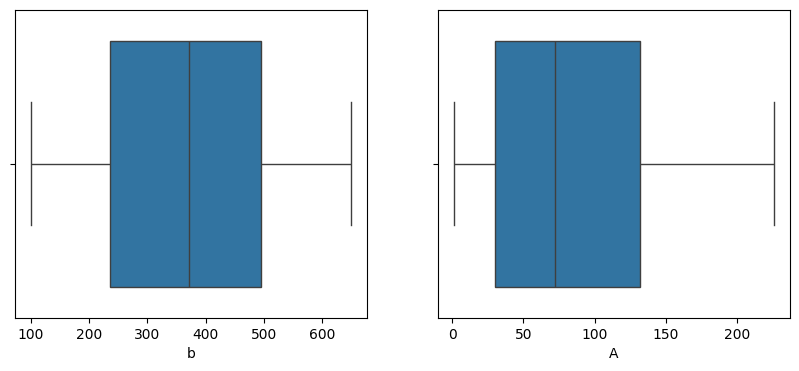

In [34]:
plt.figure(figsize=[10,4])
plt.subplot(1,2,1)
sns.boxplot(x=d2['b'])
plt.subplot(1,2,2)
sns.boxplot(x=d2['A'])
plt.show()


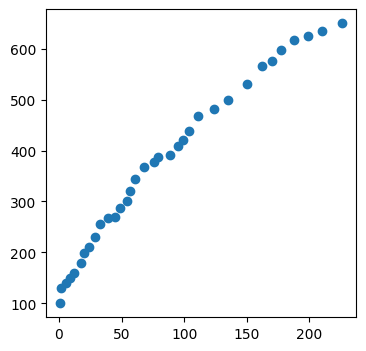

In [35]:
plt.figure(figsize=[4,4])
plt.scatter(d2['A'],d2['b'])
plt.show()

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.model_selection import train_test_split
A=d2[['A']]
b=d2['b']
A_train,A_test,b_train,b_test=train_test_split(A,b,test_size=0.20,random_state=42)

le=LinearRegression()
le.fit(A_train,b_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
res=le.predict(A_test)
print("mse:",mean_squared_error(b_test,res))
print("mae:",mean_absolute_error(b_test,res))
print("rmse:",np.sqrt(mean_squared_error(b_test,res)))
print("r2_score:",r2_score(b_test,res))

mse: 456.28458946729904
mae: 18.20115109314417
rmse: 21.36081902613519
r2_score: 0.9600545550499228


In [38]:
A_test,b_test

(      A
 15   61
 19   89
 27  162
 26  150
 8    29
 24  124
 21   99,
 15    345
 19    392
 27    567
 26    530
 8     230
 24    482
 21    421
 Name: b, dtype: int64)

In [39]:
le.predict([[162]])

c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([552.6079235])

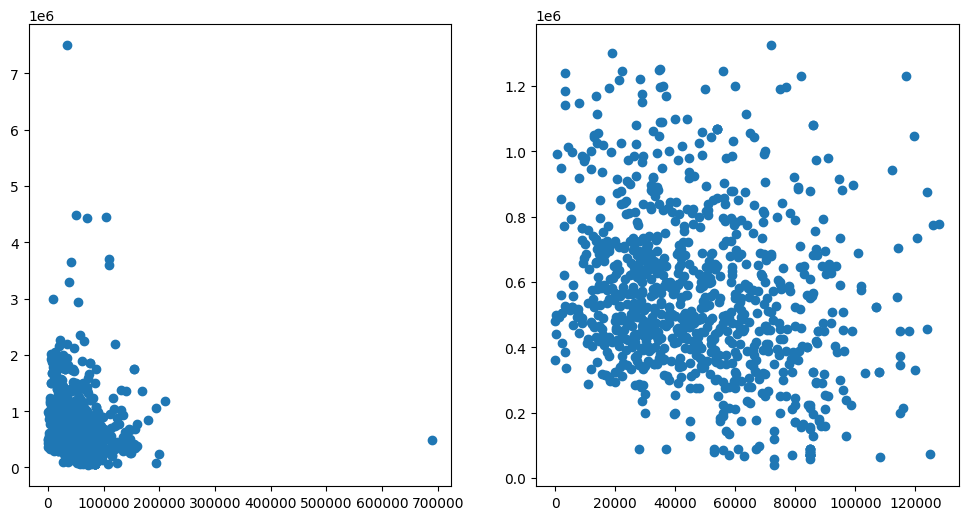

In [40]:
plt.figure(figsize=[12,6])
plt.subplot(1,2,1)
plt.scatter(d['Kms_driven'],d['Price'])
plt.subplot(1,2,2)
plt.scatter(d1['Kms_driven'],d1['Price'])
plt.show()

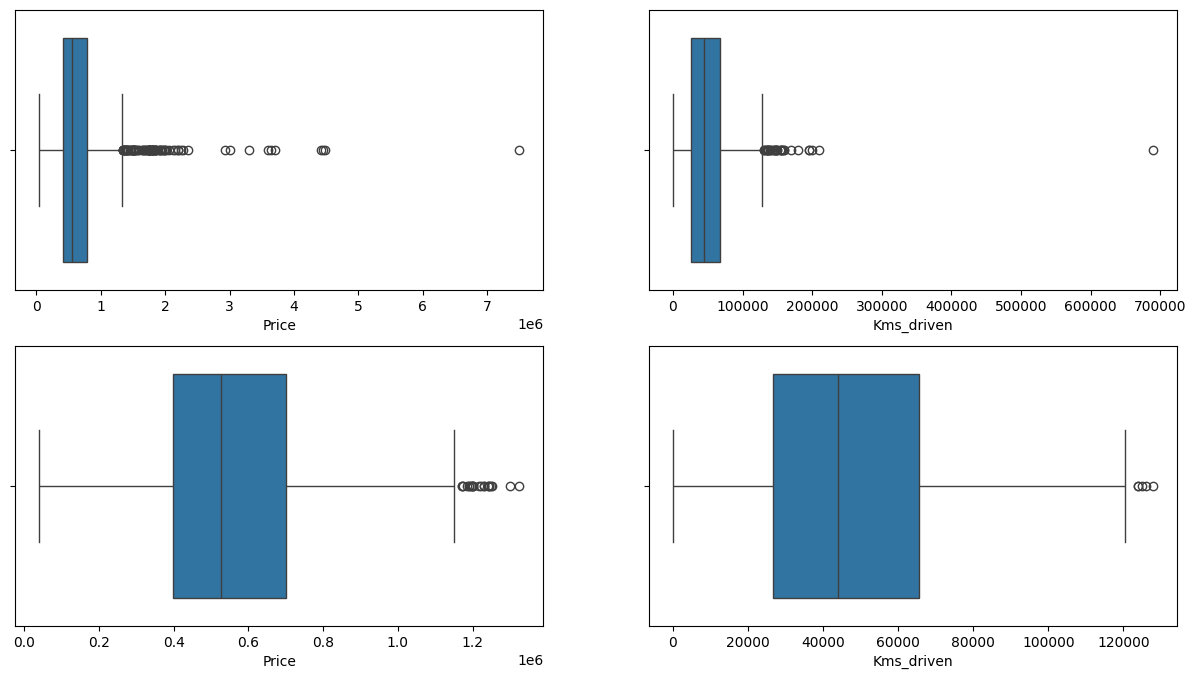

In [41]:
plt.figure(figsize=[15,8])
plt.subplot(2,2,1)
sns.boxplot(x=d['Price'])
plt.subplot(2,2,2)
sns.boxplot(x=d['Kms_driven'])
plt.subplot(2,2,3)
sns.boxplot(x=d1['Price'])
plt.subplot(2,2,4)
sns.boxplot(x=d1['Kms_driven'])
plt.show()

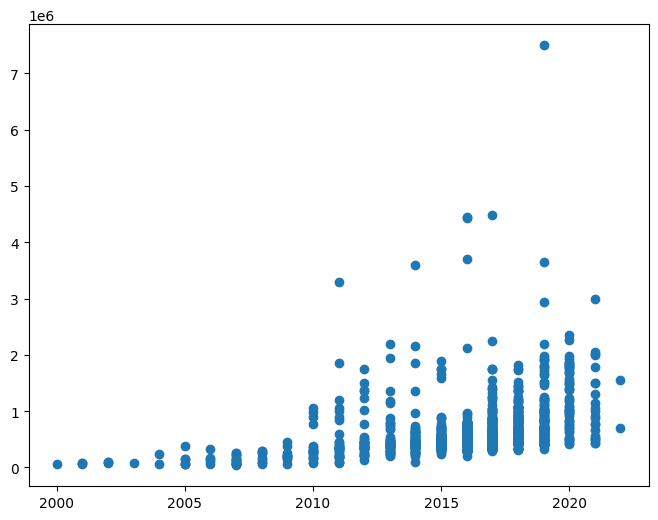

In [42]:
plt.figure(figsize=[8,6])
plt.scatter(d['Year'],d['Price'])
plt.show()

In [43]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1032 entries, 0 to 1031
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0    1032 non-null   int64 
 1   Name          1032 non-null   object
 2   Label         1032 non-null   object
 3   Location      1032 non-null   object
 4   Price         1032 non-null   int64 
 5   Kms_driven    1032 non-null   int64 
 6   Fuel_type     1032 non-null   object
 7   Owner         1032 non-null   object
 8   Year          1032 non-null   int64 
 9   Company       1032 non-null   object
 10  Owner_le      1032 non-null   int64 
 11  Fuel_type_le  1032 non-null   int64 
dtypes: int64(6), object(6)
memory usage: 96.9+ KB


In [44]:
d.describe()

,Unnamed: 0,Price,Kms_driven,Year,Owner_le,Fuel_type_le
count,1032.000000,1.032000e+03,1032.000000,1032.000000,1032.000000,1032.000000
mean,515.500000,6.857131e+05,50398.250969,2015.810078,0.784884,3.831395
std,298.057042,5.359092e+05,38159.221815,3.396920,0.451578,1.828395
min,0.000000,3.900000e+04,0.000000,2000.000000,0.000000,0.000000
25%,257.750000,4.117740e+05,26327.750000,2014.000000,1.000000,1.000000
50%,515.500000,5.595495e+05,44000.000000,2016.000000,1.000000,5.000000
75%,773.250000,7.869490e+05,67663.750000,2018.000000,1.000000,5.000000
max,1031.000000,7.500000e+06,690000.000000,2022.000000,2.000000,6.000000


In [45]:
d1.describe()

,Unnamed: 0,Price,Kms_driven,Year,Owner_le,Fuel_type_le
count,912.000000,9.120000e+02,912.000000,912.000000,912.000000,912.000000
mean,520.065789,5.624339e+05,47267.179825,2015.729167,0.780702,4.036184
std,294.632384,2.505994e+05,26520.102819,3.321107,0.456855,1.722775
min,0.000000,3.900000e+04,0.000000,2000.000000,0.000000,0.000000
25%,272.750000,3.984990e+05,26745.750000,2015.000000,1.000000,5.000000
50%,522.500000,5.269990e+05,44000.000000,2016.000000,1.000000,5.000000
75%,770.250000,7.000000e+05,65426.750000,2018.000000,1.000000,5.000000
max,1028.000000,1.325000e+06,127971.000000,2022.000000,2.000000,6.000000
